# Notebook 20 — the sediment calibration (C4.3) and the ENSO contrast (C5)

This notebook is the **executable record of the sediment results**. It reads the committed
outputs of two harnesses and re-presents them; it runs **no fit and no engine**, so it can never
drift from the numbers it reports.

- **Stage C4.3** — the sediment *calibration*: can we tune the model to match observed daily
  sediment flux? Owner document: `docs/55`. Harness: `scripts/c4/o5_calibration_profile.py`.
- **Stage C5** — the ENSO *contrast*: does the model reproduce the observed wet/dry sediment
  difference between La Niña and El Niño? Owner document: `docs/56`. Harness:
  `scripts/c5/c5_enso_contrast.py` and `c5_sensitivity.py`.

**Vocabulary, defined once.** *Suspended sediment* = fine soil carried inside river water.
*Flux* = mass of sediment past a point per day (tonnes/day) = discharge × concentration × 0.0864.
*KGE* (Kling–Gupta Efficiency) = a skill score; 1 is perfect, and the "no-skill" line (predicting
the long-term mean every day) is 1−√2 ≈ −0.414. *α* = the erosion level knob (Williams reference
11.8). *Railing* = a search hitting the edge of its allowed range because the data wants to go
beyond it. *Out-of-sample* = tested on years deliberately kept out of the calibration.

## 0 — Read the committed results (no computation performed here)

In [1]:
import os, json, pathlib
import numpy as np, pandas as pd
# anchor to the repo root so relative paths resolve wherever the notebook is executed from
_p = pathlib.Path.cwd()
while not (_p / "data" / "processed").exists() and _p != _p.parent:
    _p = _p.parent
os.chdir(_p)
PROC = pathlib.Path("data/processed")
o5  = json.loads((PROC / "o5_calibration_profile.json").read_text())   # C4.3
c4  = json.loads((PROC / "report_C4.json").read_text())                # C4.3 report card
c5  = json.loads((PROC / "c5_enso_contrast.json").read_text())         # C5 contrast
sens = pd.read_csv(PROC / "c5_sensitivity.csv")                        # C5 robustness
print("loaded:", "o5_calibration_profile", "report_C4", "c5_enso_contrast", "c5_sensitivity")
print("C4.3 verdict :", c4["verdict"])
print("C5 headline  : modelled median ratio %.2f, %d/%d stations > 1"
      % (c5["modelled"]["median_ratio"], c5["modelled"]["n_gt_1"], c5["modelled"]["n_total"]))

loaded: o5_calibration_profile report_C4 c5_enso_contrast c5_sensitivity
C4.3 verdict : RAILED / EXPLORATORY — NOT ADOPTED
C5 headline  : modelled median ratio 3.05, 18/18 stations > 1


## 1 — C4.3: the calibration rails, and that is a finding

The registered objective is the **KGE on log sediment flux** over the 8 calibration stations
(`docs/45` §3). Two free parameters: **α** (the level knob, searched in the box [2, 30]) and
**β** (the storm exponent, [0.40, 0.75]). Because α is a pure multiplier, the whole α-search is
closed-form arithmetic on the station statistics — no blind search is needed.

In [2]:
opt = o5["in_box_optimum"]; unc = o5["unconstrained_opt_beta0p56"]
print("in-box optimum  : beta %.2f, alpha %.3g -> F_report %.3f  (%s)"
      % (opt["beta"], opt["alpha"], opt["F_report"], "RAILED at box floor" if opt["railed"] else "interior"))
print("unconstrained   : alpha %.3g -> F_report %.3f  (below the plausible floor)"
      % (unc["alpha"], unc["F_report"]))
print("bar (Fagundes)  :", o5["bar"], " | no-skill line = 1 - sqrt(2) = %.3f" % (1-2**0.5))
g = o5["g12_leave_out_flowsel"]
print("G12 leave-one-out (drop flow-selective): F_report %.3f, verdict %s"
      % (g["F_report"], "FLIPS" if g["verdict_flips"] else "holds"))

in-box optimum  : beta 0.60, alpha 2 -> F_report -0.118  (RAILED at box floor)
unconstrained   : alpha 0.477 -> F_report -0.025  (below the plausible floor)
bar (Fagundes)  : [-0.26, 0.44]  | no-skill line = 1 - sqrt(2) = -0.414
G12 leave-one-out (drop flow-selective): F_report 0.197, verdict holds


**The verdict: RAILED / EXPLORATORY, not adopted.** The best in-box KGE sits at the box
*floor* (α = 2) because the data actually wants α ≈ 0.48 — far below the physical Williams value
(11.8) and below the plausible floor. In the pre-registered scheme an α that wants to be that small
is a **diagnostic** (mild upstream over-production), not a value to adopt. The reason a fitted α
would be meaningless anyway: the erosion equation multiplies seven factors the gauge network cannot
separate — the design matrix is singular (condition number ∞), so only the product Π is
identifiable, never α alone.

### Figure — the calibration rail

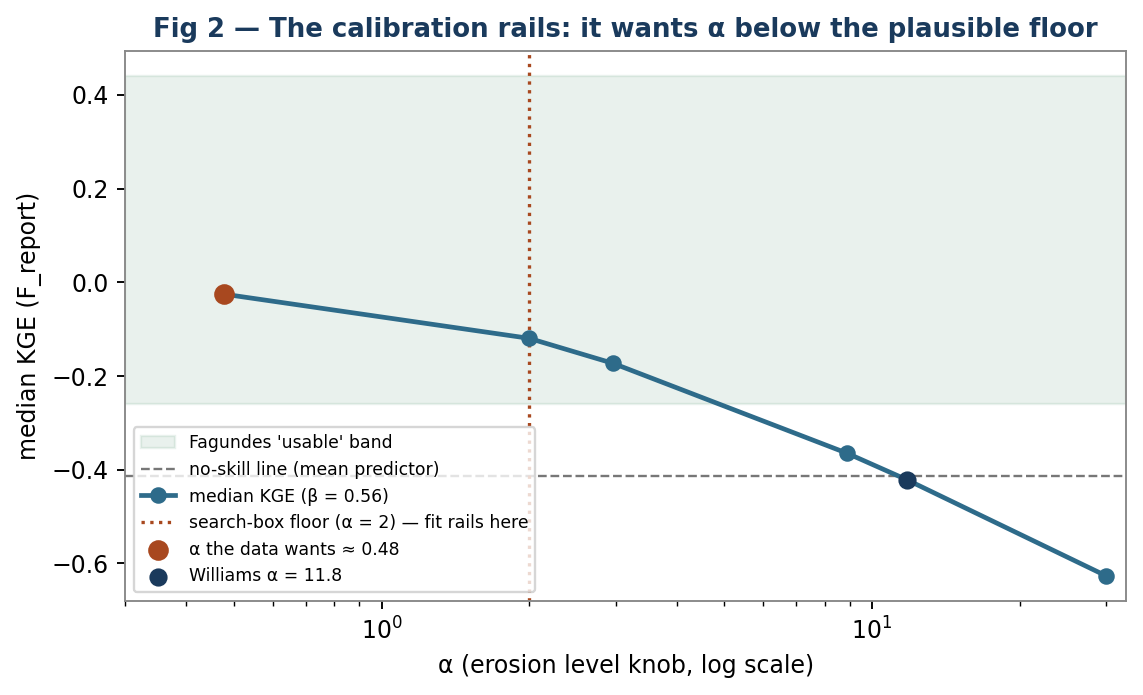

In [3]:
from IPython.display import Image, display
display(Image(filename="figures/report/fig2_kge_alpha_rail.png"))

**What is plotted.** Median sediment KGE (vertical) against the level knob α (horizontal, log scale) at β = 0.56, with the Fagundes 'usable' band and the no-skill line marked.

**What it shows.** The curve is monotone: KGE rises as α falls toward the value the data prefers (≈ 0.48), so within the allowed range the best point is the box floor (α = 2). At Williams α = 11.8 the score is −0.42.

**What it means.** The fit rails — it wants an α below the plausible floor. This is the pre-registered FAIL/RAILED outcome, read as a diagnosis of mild upstream over-production, not an adoptable calibration.

### Figure — why the score is what it is: it tracks the runoff timing

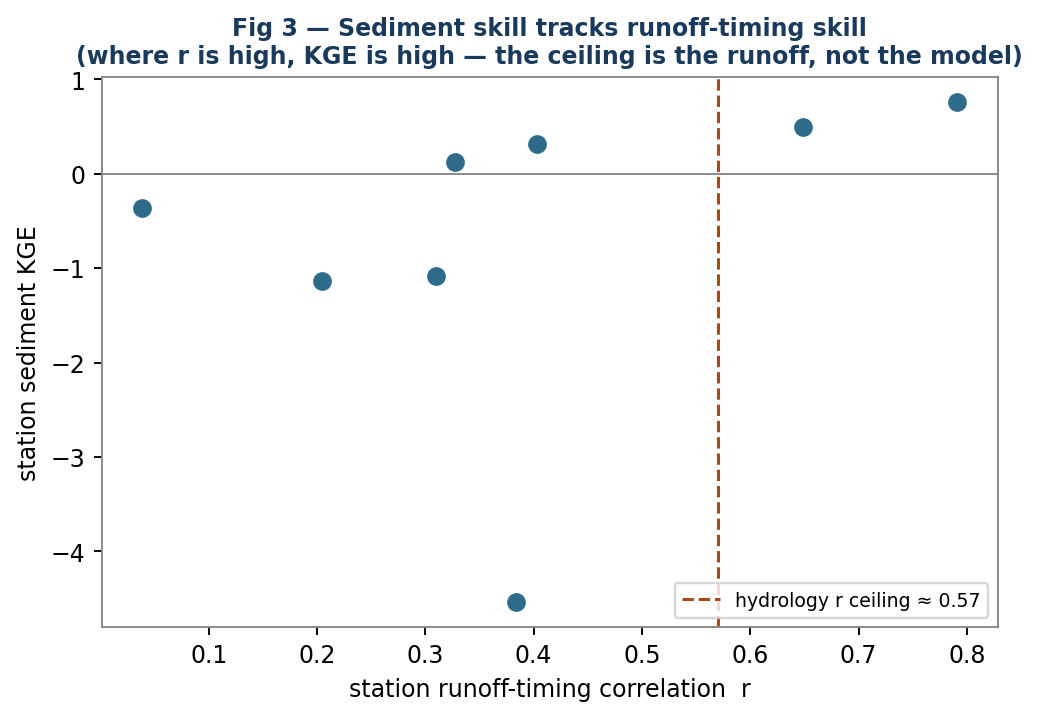

In [4]:
display(Image(filename="figures/report/fig3_kge_vs_r.png"))

**What is plotted.** Each point is one calibration station: its sediment KGE against its runoff-timing correlation r.

**What it shows.** They line up — stations whose runoff is predictable score well, those whose runoff is not score badly, with the same model and the same α. The r ≈ 0.57 hydrology ceiling is marked.

**What it means.** The ceiling on sediment skill is the runoff-timing ceiling, not the sediment physics. A KGE near 1 needs r near 1, but r is capped at ≈ 0.57 by the rainfall data — so ~0.57 is the absolute best this basin could give, and daily sediment realistically scores near zero.

## 2 — C5: the ENSO contrast — reproduced, 18/18

The scientific target is the **wet/dry ratio** of sediment rate: mean flux in La Niña 2011 divided
by mean flux across El Niño 2015–16. This ratio is **invariant to α and to the LS level** — both
are static multipliers that cancel top-and-bottom — so it survives the C4.3 railing entirely. It
depends only on the runoff contrast the rainfall carries between the two regimes.

In [5]:
m = c5["modelled"]
print("modelled contrast: median %.2f, geo-mean %.2f, range %.2f-%.2f, %d/%d stations La Nina > El Nino"
      % (m["median_ratio"], m["geomean"], m["range"][0], m["range"][1], m["n_gt_1"], m["n_total"]))
print("observed (docs/34): median ~3-5 primary; 22/22 station-ratios > 1")
print("reference estimator (b) 2.84-2.95; noisier estimator (a) 4.62 -> modelled 3.05 matches (b)")

modelled contrast: median 3.05, geo-mean 3.06, range 1.62-4.85, 18/18 stations La Nina > El Nino
observed (docs/34): median ~3-5 primary; 22/22 station-ratios > 1
reference estimator (b) 2.84-2.95; noisier estimator (a) 4.62 -> modelled 3.05 matches (b)


### Figure — modelled vs observed contrast, all 18 stations

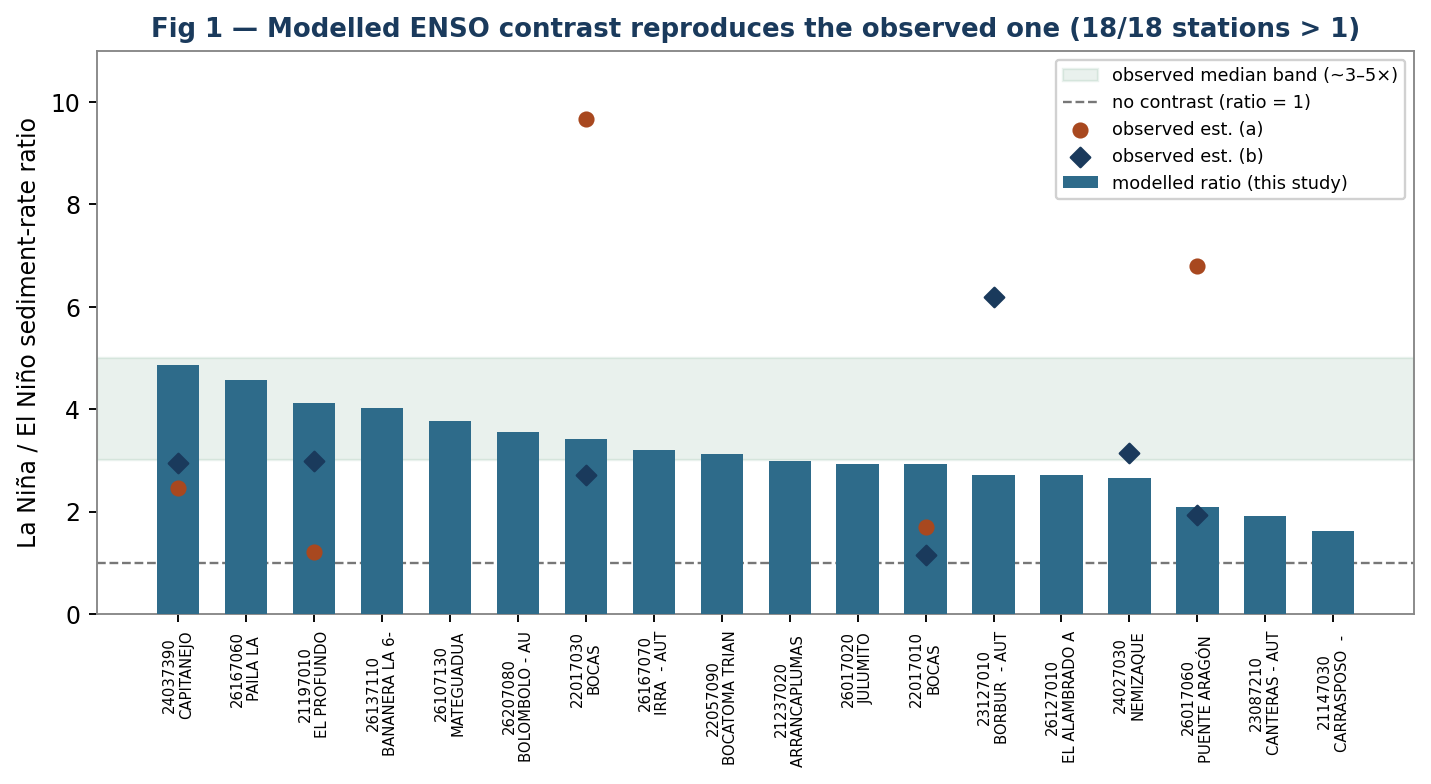

In [6]:
display(Image(filename="figures/report/fig1_enso_contrast.png"))

**What is plotted.** For each of the 18 stations: the modelled wet/dry ratio (bar) with the two observed estimators overlaid (points), the ~3–5× observed band shaded, and the ratio = 1 line.

**What it shows.** Every modelled bar exceeds 1; the modelled median (3.05) sits inside the observed band and matches the smoother rating estimator (b). Direction agrees at all 18 stations.

**What it means.** The model reproduces the ENSO sediment contrast — the study's positive result — despite a weak absolute calibration, because the ratio cancels the unidentifiable multipliers.

### Figure — robustness: the direction never reverses

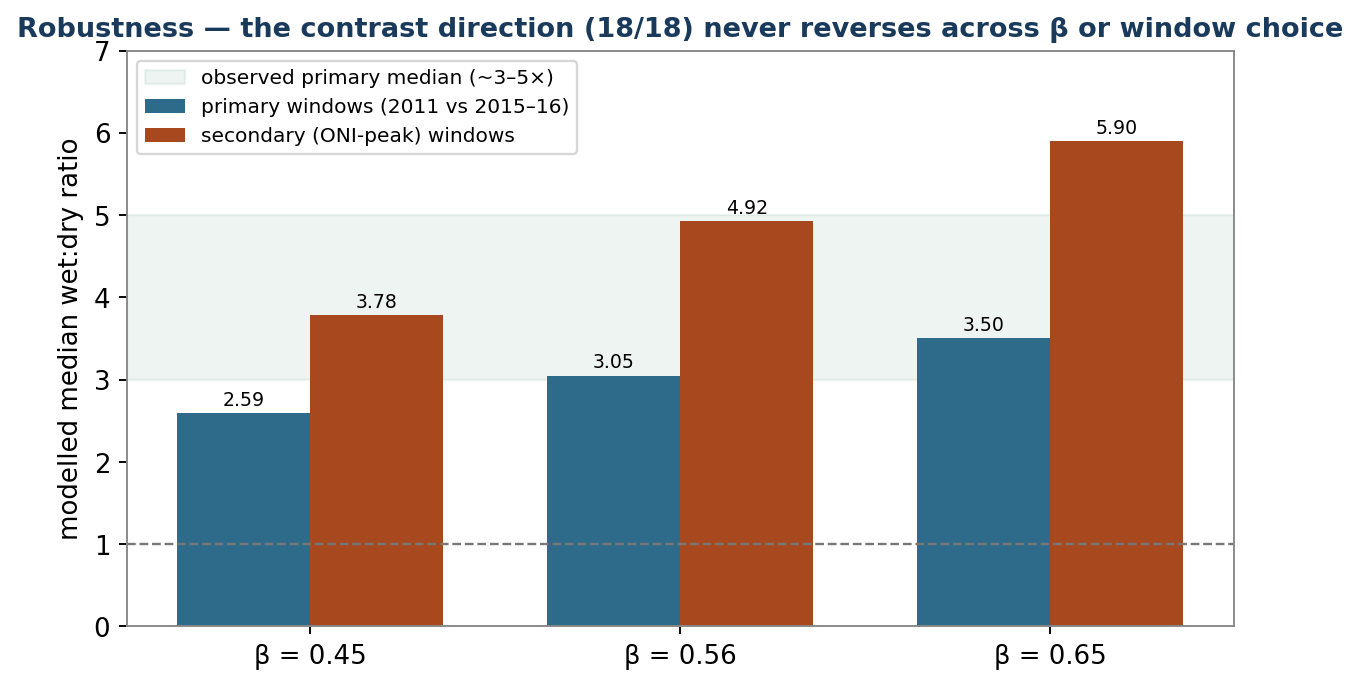

In [7]:
display(Image(filename="figures/deck/gen_sensitivity_detail.png"))

**What is plotted.** The modelled median ratio for three storm exponents β × two window definitions (primary and the sharper ONI-peak secondary windows).

**What it shows.** All six cells are above 1 — the direction (La Niña > El Niño) holds everywhere. The magnitude varies (~2.6 to ~5.9×); the sharper windows give the larger contrast, as the observations do.

**What it means.** The result is not an artefact of a modelling choice. β and window definition move the magnitude but never the sign.

## 3 — Reproduction gates (the numbers this notebook must reproduce)

In [8]:
assert c4["verdict"].startswith("RAILED"), "C4.3 verdict changed"
assert c5["modelled"]["n_gt_1"] == c5["modelled"]["n_total"] == 18, "C5 direction changed"
assert abs(c5["modelled"]["median_ratio"] - 3.05) < 0.02, "C5 median moved"
allpos = (sens["n_gt1"] == sens["n"]).all()
assert allpos, "a sensitivity cell reversed direction"
print("GATES PASS: C4.3 RAILED/EXPLORATORY; C5 18/18, median 3.05; sensitivity 18/18 in every cell")

GATES PASS: C4.3 RAILED/EXPLORATORY; C5 18/18, median 3.05; sensitivity 18/18 in every cell


## 4 — The two-level result, in one paragraph

At the level of **absolute daily prediction** the sediment model is weak (KGE near zero) and rails
under calibration — not because of the sediment physics, but because the rainfall data caps runoff
timing at r ≈ 0.57, a ceiling proven unliftable (`docs/58`, ≤ +0.006). At the level of the **ENSO
contrast** — the question the study exists to answer — the model succeeds: it reproduces the
observed ~3× wet/dry ratio at 18 of 18 stations, robustly and out-of-sample, because the contrast
cancels the parts of the model that are not identifiable. Absolute yields (t/km²/yr) are not
reported — the catchment areas are under embargo (`docs/23` §13.2); all results are ratios or
basin-internal fluxes.